## Import Libraries


In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
import plotly.express as px
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from livelossplot.tf_keras import PlotLossesCallback
import spacy

import warnings
# Ignore all warnings
warnings.filterwarnings('ignore')

plt.style.use("ggplot")
print(f"GPU Detected: {tf.config.list_physical_devices('GPU')} ")

GPU Detected: [] 


In [108]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/entity-annotated-corpus/ner.csv
/kaggle/input/entity-annotated-corpus/ner_dataset.csv


## Loading Data

In [109]:
df = pd.read_csv("/kaggle/input/entity-annotated-corpus/ner_dataset.csv",encoding="latin1")

In [110]:
df.head(10)

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O
5,NaN,through,IN,O
6,NaN,London,NNP,B-geo
7,NaN,to,TO,O
8,NaN,protest,VB,O
9,NaN,the,DT,O


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Sentence #  47959 non-null    object
 1   Word        1048565 non-null  object
 2   POS         1048575 non-null  object
 3   Tag         1048575 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB


In [112]:
df = df.fillna(method="ffill")

## EDA & Text Transformation

In [113]:
print(f"# words in Corpus: {df['Word'].nunique()}")
print(f"# Tags in Corpus: {df['Tag'].nunique()}")

# words in Corpus: 35177
# Tags in Corpus: 17


In [114]:
df['Tag'].value_counts()

Tag
O        887908
B-geo     37644
B-tim     20333
B-org     20143
I-per     17251
B-per     16990
I-org     16784
B-gpe     15870
I-geo      7414
I-tim      6528
B-art       402
B-eve       308
I-art       297
I-eve       253
B-nat       201
I-gpe       198
I-nat        51
Name: count, dtype: int64

In [115]:
words = list(set(df["Word"].values))
words.append("ENDTEXT")
num_words = len(words)
print(num_words)

35178


In [116]:
words[-1]

'ENDTEXT'

In [117]:
tags = list(set(df["Tag"].values))
num_tags = len(tags)

### Essential Information about Entities

- **geo**: Geographical Entity
- **org**: Organization
- **per**: Person
- **gpe**: Geopolitical Entity
- **tim**: Time Indicator
- **art**: Artifact
- **eve**: Event
- **nat**: Natural Phenomenon


In [118]:
px.histogram(df[~df.Tag.str.contains("O")],x="Tag",color="Tag")

### Tokens Integration

In [119]:
def sentence_integrate(data):
  agg_func = lambda s: [(w, p, t) for w, p, t in zip(s["Word"].values.tolist(),
                                                     s["POS"].values.tolist(),
                                                     s["Tag"].values.tolist())]
  return data.groupby('Sentence #').apply(agg_func).tolist()
  

In [120]:
sentences=sentence_integrate(df)
  
sentences[2]

[('Helicopter', 'NN', 'O'),
 ('gunships', 'NNS', 'O'),
 ('Saturday', 'NNP', 'B-tim'),
 ('pounded', 'VBD', 'O'),
 ('militant', 'JJ', 'O'),
 ('hideouts', 'NNS', 'O'),
 ('in', 'IN', 'O'),
 ('the', 'DT', 'O'),
 ('Orakzai', 'NNP', 'B-geo'),
 ('tribal', 'JJ', 'O'),
 ('region', 'NN', 'O'),
 (',', ',', 'O'),
 ('where', 'WRB', 'O'),
 ('many', 'JJ', 'O'),
 ('Taliban', 'NNP', 'B-org'),
 ('militants', 'NNS', 'O'),
 ('are', 'VBP', 'O'),
 ('believed', 'VBN', 'O'),
 ('to', 'TO', 'O'),
 ('have', 'VB', 'O'),
 ('fled', 'VBN', 'O'),
 ('to', 'TO', 'O'),
 ('avoid', 'VB', 'O'),
 ('an', 'DT', 'O'),
 ('earlier', 'JJR', 'O'),
 ('military', 'JJ', 'O'),
 ('offensive', 'NN', 'O'),
 ('in', 'IN', 'O'),
 ('nearby', 'JJ', 'O'),
 ('South', 'NNP', 'B-geo'),
 ('Waziristan', 'NNP', 'I-geo'),
 ('.', '.', 'O')]

### Tokens Indexing

In [121]:
word2idx = {w: i for i, w in enumerate(words,start=1)}
tag2idx = {t: i for i, t in enumerate(tags)}

In [122]:
# word2idx

In [123]:
# tag2idx

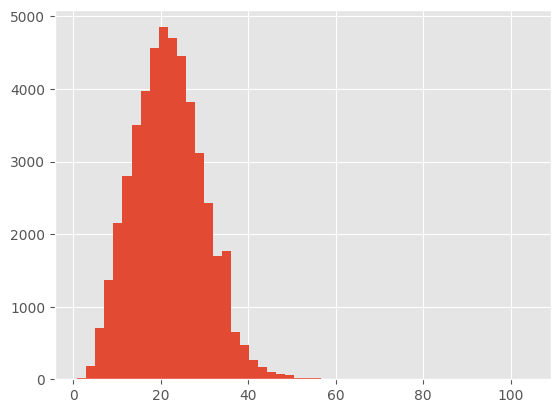

In [124]:
plt.hist([len(x) for x in sentences],bins=50)
plt.show()

### Padding Tokens

In [125]:
max_len = 50

In [126]:
X = [[word2idx[w[0]]for w in s]for s in sentences]
X = pad_sequences(sequences = X, maxlen=max_len, padding='post',value=num_words-1)

In [127]:
X[0]

array([ 6152,  9276,  4966, 11525, 33510, 33029, 34706, 34649,  3684,
        5259, 29140, 10048, 32736,   924, 15547,  5259,  7779,  9276,
       22522, 31087, 12428, 34369, 12070, 29696, 35177, 35177, 35177,
       35177, 35177, 35177, 35177, 35177, 35177, 35177, 35177, 35177,
       35177, 35177, 35177, 35177, 35177, 35177, 35177, 35177, 35177,
       35177, 35177, 35177, 35177, 35177], dtype=int32)

In [128]:
y = [[tag2idx[w[2]] for w in s] for s in sentences]
y = pad_sequences(maxlen=max_len, sequences=y, padding="post", value=tag2idx["O"])

In [129]:
y[0]

array([7, 7, 7, 7, 7, 7, 4, 7, 7, 7, 7, 7, 4, 7, 7, 7, 7, 7, 9, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7], dtype=int32)

### Splitting Data

In [130]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Building and Testing Model

In [131]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_len,)),  # Input layer with shape (50,)
    tf.keras.layers.Embedding(input_dim=num_words, output_dim=max_len, input_length=max_len),  # Embedding layer
    tf.keras.layers.SpatialDropout1D(0.2),  # Spatial Dropout
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(100, return_sequences=True)),  # Bidirectional LSTM
    tf.keras.layers.Dense(len(tag2idx), activation='softmax')  # Output layer with softmax activation
])

In [132]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 50)         │     1,758,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 50, 50)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 50, 200)        │       120,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50, 17)         │         3,417 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,883,117 (7.18 MB)

 Trainable params: 1,883,117 (7.18 MB)

 Non-trainable params: 0 (0.00 B)

In [133]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [134]:
logdir = "log/"
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

# Update the filename to end with `.weights.h5`
chkpt = ModelCheckpoint("model_weights.weights.h5", monitor='val_loss', verbose=1, save_best_only=True, save_weights_only=True, mode='min')

early_stopping = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=1, verbose=0, mode='max', baseline=None, restore_best_weights=False)

callbacks = [PlotLossesCallback(), chkpt, early_stopping, tensorboard_callback]


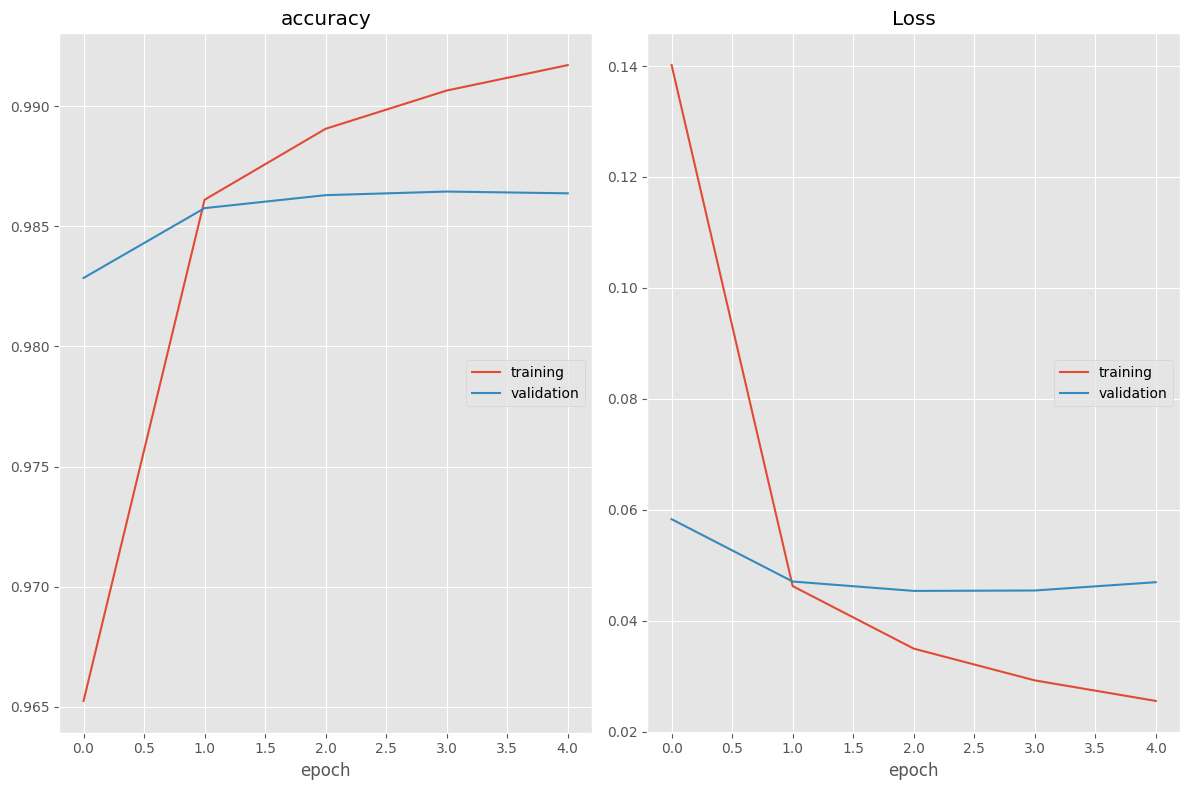

accuracy
	training         	 (min:    0.965, max:    0.992, cur:    0.992)
	validation       	 (min:    0.983, max:    0.986, cur:    0.986)
Loss
	training         	 (min:    0.026, max:    0.140, cur:    0.026)
	validation       	 (min:    0.045, max:    0.058, cur:    0.047)

Epoch 5: val_loss did not improve from 0.04537
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 99s 64ms/step - accuracy: 0.9920 - loss: 0.0249 - val_accuracy: 0.9864 - val_loss: 0.0469


In [135]:
history = model.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_test, y_test),
    batch_size=25, 
    epochs=10,
    verbose=1,
    callbacks=callbacks
)

## Evalution

In [136]:
results = model.evaluate(x_test, y_test, batch_size=128)
print(f"Test Accuracy: {round(results[1],3)}\nTest Loss: {round(results[0],3)}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9863 - loss: 0.0477
Test Accuracy: 0.986
Test Loss: 0.047


## Deployment

In [137]:
model.save("ner_model.h5")

## Inferencing Model

### Preprocess the Input Sentence

In [138]:
# Example sentence
new_sentence = """Apple Inc. was founded by Steve Jobs, Steve Wozniak,
                  and Ronald Wayne in Cupertino, California, in April 1976."""

In [139]:
# Tokenize the sentence (split into words)
words = new_sentence.split()

# Convert words to their corresponding indices
word_indices = [word2idx.get(w, 0) for w in words]  # Use 0 if the word is not found

# Pad the sequence
max_len = 50  # This should match the padding length used during training
padded_sequence = pad_sequences([word_indices], maxlen=max_len, padding="post", value=num_words-1)


###  Load the Trained Model

In [140]:
from tensorflow.keras.models import load_model

# Load the model (replace 'model_path' with the path to your saved model)
model = load_model("ner_model.h5")


### Prediction

In [141]:
# Make a prediction
y_pred = model.predict(padded_sequence)

# Convert predictions to tag indices (e.g., get the index of the max value in each output vector)
pred_tags = np.argmax(y_pred, axis=-1)[0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


### Post-process the Output

In [142]:
idx2tag = {i: t for t, i in tag2idx.items()}  # Reverse the tag2idx dictionary

# Map the predicted indices to their tags
predicted_tags = [idx2tag[idx] for idx in pred_tags]

### Spacy model

In [143]:
import spacy
nlp = spacy.load("en_core_web_sm")
doc = nlp(new_sentence)

### Display the Results

In [144]:
# Display the results
print("Word".ljust(15), "Predicted Tag".ljust(15), "spaCy POS Tag".ljust(15), "NER Entity".ljust(30), "NER Label")
print("-" * 90)

for word, tag, token in zip(words, predicted_tags, doc):
    # Find the corresponding entity if it exists
    entity = ""
    label = ""
    for ent in doc.ents:
        if word in ent.text:
            entity = ent.text
            label = ent.label_
            break

    # Print the word, predicted tag, spaCy POS tag, and NER entity and label
    print(f"{word.ljust(15)} {tag.ljust(15)} {token.pos_.ljust(15)} {entity.ljust(30)} {label}")


Word            Predicted Tag   spaCy POS Tag   NER Entity                     NER Label
------------------------------------------------------------------------------------------
Apple           B-org           PROPN           Apple Inc.                     ORG
Inc.            I-org           PROPN           Apple Inc.                     ORG
was             O               AUX                                            
founded         O               VERB                                           
by              O               ADP                                            
Steve           B-per           PROPN           Steve Jobs                     PERSON
Jobs,           I-per           PROPN                                          
Steve           I-per           PUNCT           Steve Jobs                     PERSON
Wozniak,        I-per           PROPN                                          
and             O               PROPN                                          
Ro

# Thanks